<img src="../assets/ga-logo.png" style="float: left; margin: 20px; height: 55px">

# Modeling Workflow (Walkthrough) 

---

### About
Model data from scratch: gather data, clean it, explore it, and then evaluate several models.

### Learning Objectives
- Gather, clean, explore and model a dataset from scratch.
- Split data into testing and training sets using both train/test split and cross-validation and apply both techniques to score a model.
- Evaluate several models.


### Notebook Guide

- Importing libaries
- Load the Data
- Data Cleaning:
     - Initial check
     - Clean up PhD column
     - Clean up Grad.Rate column
     - Clean up Apps column
- Stateless Feature Engineering:
     - Binarize Private column
     - Create a new feature
     - Bin Outstate column
- EDA:
     - Create Histograms of All Numerical Columns
     - Plot a Heatmap of the Correlation Matrix
     - Use seaborn's .pairplot() method to create scatterplots
     - Use seaborn's `.pairplot()` method to create scatterplots
- Model Prep:
     - Create our features matrix (`X`) and target vector (`y`)
     - Train/test split
     - Imputing Missing Values
     - Ordinal Encoding
     - Robust Scaling
     - Instantiate and train our model
- Evaluation
- LINE Assumptions

# Importing libaries
---

We'll need the following libraries for today's lesson:

1. `pandas`
2. `numpy`
3. `seaborn`
4. `matplotlib.pyplot`
4. `train_test_split` and `cross_val_score` from `sklearn`'s `model_selection` module
5. `LinearRegression` from `sklearn`'s `linear_model` module
6. `StandardScaler` from `sklearn`'s `preprocessing` module
7. `mean_squared_error` from `sklearn`'s `metrics` module 

In [119]:
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression

from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from sklearn.preprocessing import PowerTransformer

from sklearn.impute import SimpleImputer

from sklearn.model_selection import train_test_split, cross_val_score

from sklearn.metrics import mean_squared_error, mean_absolute_error, root_mean_squared_error

# Load the Data

---

Today's [data set](http://www-bcf.usc.edu/~gareth/ISL/data.html) (`College.csv`) is from the [ISLR website](https://cran.r-project.org/web/packages/ISLR/ISLR.pdf) on page 5. 

Rename `Unnamed: 0` to `University`.

In [120]:
college_df = pd.read_csv("College.csv")
college_df.rename(columns={'Unnamed: 0': 'University'}, inplace=True)
college_df

,University,Private,Apps,Accept,Enroll,Top10perc,Top25perc,F.Undergrad,P.Undergrad,Outstate,Room.Board,Books,Personal,PhD,Terminal,S.F.Ratio,perc.alumni,Expend,Grad.Rate
0,Abilene Christian University,Yes,1660,1232,721,23,52,2885,537,7440,3300,450,2200,70,78,18.1,12,7041,60
1,Adelphi University,Yes,2186,1924,512,16,29,2683,1227,12280,6450,750,1500,29,30,12.2,16,10527,56
2,Adrian College,Yes,1428,1097,336,22,50,1036,99,11250,3750,400,1165,53,66,12.9,30,8735,54
3,Agnes Scott College,Yes,417,349,137,60,89,510,63,12960,5450,450,875,92,97,7.7,37,19016,59
4,Alaska Pacific University,Yes,193,146,55,16,44,249,869,7560,4120,800,1500,76,72,11.9,2,10922,15
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
772,Worcester State College,No,2197,1515,543,4,26,3089,2029,6797,3900,500,1200,60,60,21.0,14,4469,40
773,Xavier University,Yes,1959,1805,695,24,47,2849,1107,11520,4960,600,1250,73,75,13.3,31,9189,83
774,Xavier University of Louisiana,Yes,2097,1915,695,34,61,2793,166,6900,4200,617,781,67,75,14.4,20,8323,49
775,Yale University,Yes,10705,2453,1317,95,99,5217,83,19840,6510,630,2115,96,96,5.8,49,40386,99


# Data cleaning: Initial check
---

Check the following in the cells below:
1. Do we have any null values?
2. Are any numerical columns being read in as `object`?
3. Any values outside acceptable range?

In [121]:
# 1. Check for nulls
college_df.isnull().mean().sort_values(ascending=False)*100

University     0.0
Private        0.0
Apps           0.0
Accept         0.0
Enroll         0.0
Top10perc      0.0
Top25perc      0.0
F.Undergrad    0.0
P.Undergrad    0.0
Outstate       0.0
Room.Board     0.0
Books          0.0
Personal       0.0
PhD            0.0
Terminal       0.0
S.F.Ratio      0.0
perc.alumni    0.0
Expend         0.0
Grad.Rate      0.0
dtype: float64

In [122]:
# 2. Check column data types
print("\nData set info:")
college_df.info()


Data set info:
<class 'pandas.DataFrame'>
RangeIndex: 777 entries, 0 to 776
Data columns (total 19 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   University   777 non-null    str    
 1   Private      777 non-null    str    
 2   Apps         777 non-null    int64  
 3   Accept       777 non-null    int64  
 4   Enroll       777 non-null    int64  
 5   Top10perc    777 non-null    int64  
 6   Top25perc    777 non-null    int64  
 7   F.Undergrad  777 non-null    int64  
 8   P.Undergrad  777 non-null    int64  
 9   Outstate     777 non-null    int64  
 10  Room.Board   777 non-null    int64  
 11  Books        777 non-null    int64  
 12  Personal     777 non-null    int64  
 13  PhD          777 non-null    str    
 14  Terminal     777 non-null    int64  
 15  S.F.Ratio    777 non-null    float64
 16  perc.alumni  777 non-null    int64  
 17  Expend       777 non-null    int64  
 18  Grad.Rate    777 non-null    int64  
dtypes: 

In [123]:
# 3. Check summary statistics
print("\nSummary statistics:")
college_df.describe()


Summary statistics:


,Apps,Accept,Enroll,Top10perc,Top25perc,F.Undergrad,P.Undergrad,Outstate,Room.Board,Books,Personal,Terminal,S.F.Ratio,perc.alumni,Expend,Grad.Rate
count,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.00000
mean,3001.638353,2018.804376,779.972973,27.558559,55.796654,3699.907336,855.298584,10440.669241,4357.526384,549.380952,1340.642214,79.702703,14.089704,22.743887,9660.171171,65.46332
std,3870.201484,2451.113971,929.176190,17.640364,19.804778,4850.420531,1522.431887,4023.016484,1096.696416,165.105360,677.071454,14.722359,3.958349,12.391801,5221.768440,17.17771
min,81.000000,72.000000,35.000000,1.000000,9.000000,139.000000,1.000000,2340.000000,1780.000000,96.000000,250.000000,24.000000,2.500000,0.000000,3186.000000,10.00000
25%,776.000000,604.000000,242.000000,15.000000,41.000000,992.000000,95.000000,7320.000000,3597.000000,470.000000,850.000000,71.000000,11.500000,13.000000,6751.000000,53.00000
50%,1558.000000,1110.000000,434.000000,23.000000,54.000000,1707.000000,353.000000,9990.000000,4200.000000,500.000000,1200.000000,82.000000,13.600000,21.000000,8377.000000,65.00000
75%,3624.000000,2424.000000,902.000000,35.000000,69.000000,4005.000000,967.000000,12925.000000,5050.000000,600.000000,1700.000000,92.000000,16.500000,31.000000,10830.000000,78.00000
max,48094.000000,26330.000000,6392.000000,96.000000,100.000000,31643.000000,21836.000000,21700.000000,8124.000000,2340.000000,6800.000000,100.000000,39.800000,64.000000,56233.000000,118.00000


# Data cleaning: Clean up `PhD` column
---

`PhD` is being read in as a string because some of the cells contain non-numerical values. 

In the cell below:
1. replace any non-numerical values with `NaN`'s
2. change the column datatype to float
3. Verify the number of missing values

In [124]:
# 1. and 2.
college_df['PhD'] = college_df['PhD'].replace('?', np.nan)

In [125]:
college_df['PhD'] = college_df['PhD'].astype(float)

In [126]:
# 3.
college_df.isnull().mean().sort_values(ascending=False)*100

PhD            3.732304
Private        0.000000
University     0.000000
Apps           0.000000
Accept         0.000000
Top10perc      0.000000
Enroll         0.000000
F.Undergrad    0.000000
P.Undergrad    0.000000
Outstate       0.000000
Top25perc      0.000000
Room.Board     0.000000
Books          0.000000
Personal       0.000000
Terminal       0.000000
S.F.Ratio      0.000000
perc.alumni    0.000000
Expend         0.000000
Grad.Rate      0.000000
dtype: float64

`PhD` should now contain missing values.

1. Suggest a strategy to deal with it.

**NOTE**: If you decide to substitute with plausible values, DO NOT APPLY IT YET HERE.

In [178]:
# Your suggestions
# I would handle the missing values in the PhD column by imputing them
# with the median, but I will apply this after the train/test split
# to avoid data leakage.

We weren't able to describe `PhD` using summary statistics as its type was `ogject`

1. Apply `.describe()` to the column
2. Any values out of normal range?
3. Suggest a strategy to fix the errors, if any.

In [128]:
# 1.
print("\nSummary statistics:")
college_df['PhD'].describe()


Summary statistics:


count    748.000000
mean      72.518717
std       16.315199
min        8.000000
25%       62.000000
50%       75.000000
75%       85.000000
max      103.000000
Name: PhD, dtype: float64

In [129]:
# 2. 
college_df[(college_df['PhD'] < 0) | (college_df['PhD'] > 100)]


,University,Private,Apps,Accept,Enroll,Top10perc,Top25perc,F.Undergrad,P.Undergrad,Outstate,Room.Board,Books,Personal,PhD,Terminal,S.F.Ratio,perc.alumni,Expend,Grad.Rate
582,Texas A&M University at Galveston,No,529,481,243,22,47,1206,134,4860,3122,600,650,103.0,88,17.4,16,6415,43


In [130]:
# 3. 
# I will replace these invalid values with NaN.
college_df.loc[
    (college_df['PhD'] < 0) | (college_df['PhD'] > 100),
    'PhD'
] = np.nan


# Data cleaning: Clean up `Grad.Rate` column
---

`Grad.Rate` is the graduation rate, but it has data entry errors.

1. Suggest a strategy to fix the errors and apply it

_HINT: check the rows where the errors take place_

In [131]:
college_df[(college_df["Grad.Rate"]>100) | (college_df["Grad.Rate"]<0)]

,University,Private,Apps,Accept,Enroll,Top10perc,Top25perc,F.Undergrad,P.Undergrad,Outstate,Room.Board,Books,Personal,PhD,Terminal,S.F.Ratio,perc.alumni,Expend,Grad.Rate
95,Cazenovia College,Yes,3847,3433,527,9,35,1010,12,9384,4840,600,500,22.0,47,14.3,20,7697,118


In [132]:
college_df.loc[college_df['Grad.Rate'] > 100, 'Grad.Rate'] = 100

# Data cleaning: Clean up `Apps` column
---

1. Are there any outliers in the `Apps` column? Can you safely remove any?

In [133]:
college_df["Apps"].describe()

count      777.000000
mean      3001.638353
std       3870.201484
min         81.000000
25%        776.000000
50%       1558.000000
75%       3624.000000
max      48094.000000
Name: Apps, dtype: float64

<Axes: xlabel='Apps'>

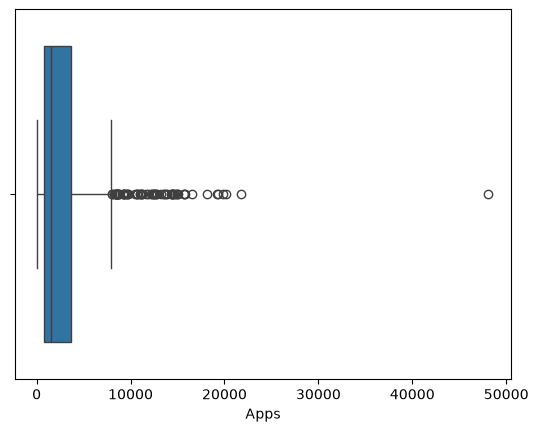

In [134]:
sns.boxplot(x=college_df['Apps'])

In [135]:
Q1 = college_df['Apps'].quantile(0.25)
Q3 = college_df['Apps'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

college_df[(college_df['Apps'] < lower_bound) | (college_df['Apps'] > upper_bound)]

,University,Private,Apps,Accept,Enroll,Top10perc,Top25perc,F.Undergrad,P.Undergrad,Outstate,Room.Board,Books,Personal,PhD,Terminal,S.F.Ratio,perc.alumni,Expend,Grad.Rate
23,Arizona State University Main campus,No,12809,10308,3761,24,49,22593,7585,7434,4850,700,2100,88.0,93,18.9,5,4602,48
59,Boston University,Yes,20192,13007,3810,45,80,14971,3113,18420,6810,475,1025,80.0,81,11.9,16,16836,72
61,Bowling Green State University,No,9251,7333,3076,14,45,13699,1213,7452,3352,600,1700,81.0,89,21.1,14,6918,67
70,Brown University,Yes,12586,3239,1462,87,95,5643,349,19528,5926,720,1100,99.0,100,7.6,39,20440,97
87,Carnegie Mellon University,Yes,8728,5201,1191,60,89,4265,291,17900,5690,450,1250,86.0,93,9.2,31,24386,74
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
694,University of Washington,No,12749,7025,3343,40,81,20356,4582,8199,4218,708,2172,96.0,94,9.0,10,16527,65
700,University of Wisconsin at Madison,No,14901,10932,4631,36,80,23945,2200,9096,4290,535,1545,93.0,96,11.5,20,11006,72
713,Virginia Tech,No,15712,11719,4277,29,53,18511,604,10260,3176,740,2200,85.0,89,13.8,20,8944,73
743,Western Michigan University,No,9167,7191,2738,24,53,15739,4278,6940,4100,500,1700,80.0,84,24.7,11,5983,55


In [136]:
#No, not just based on being statistical outliers

# Stateless Feature Engineering: Binarize `Private` column
---

In the cells below, convert the `Private` column into numerical values.

In [137]:
college_df = pd.get_dummies(college_df, columns=['Private'], drop_first=True, dtype=int)

In [138]:
college_df.rename(columns={"Private_Yes": "Private"}, inplace=True)
college_df["Private"]

0      1
1      1
2      1
3      1
4      1
      ..
772    0
773    1
774    1
775    1
776    1
Name: Private, Length: 777, dtype: int64

# Stateless Feature Engineering: Create a new feature 
---

An acceptance rate is more meaningful than the counts of applicants and accepted students on their own. It represents the proportion of applicants who were accepted.

1. Create a new feature `Accept.Rate` and save it back to our dataframe

In [139]:
college_df["Accept.Rate"] = college_df["Accept"] / college_df["Apps"]

In [140]:
college_df[["Apps", "Accept", "Accept.Rate"]]

,Apps,Accept,Accept.Rate
0,1660,1232,0.742169
1,2186,1924,0.880146
2,1428,1097,0.768207
3,417,349,0.836930
4,193,146,0.756477
...,...,...,...
772,2197,1515,0.689577
773,1959,1805,0.921388
774,2097,1915,0.913209
775,10705,2453,0.229145


# Stateless Feature Engineering: Bin `Outstate ` column
---

1. Create a new column `Outstate.Tier` to split out-of-state tuition into bins. Use the following thresholds:
- 0 - 8,000: Low
- 8,000 - 12,000: Medium
- 12,000 - 16,000: High
- 16,000 and up: Very High



In [141]:
# Create Outstate.Tier
college_df["Outstate.Tier"] = pd.cut(
    college_df["Outstate"],
    bins=[0, 8000, 12000, 16000, float("inf")],
    labels=["Low", "Medium", "High", "Very High"],
    include_lowest=True
)

In [142]:
# Let's ordinal encode the 'Outstate.Tier' variable since it has a natural order

# Step 0. Create a list of your labels in ascending order
tier_label = ['Low', 'Medium', 'High', 'Very High']

# Step 1. Instantiate the transformer
o_enc = OrdinalEncoder(
    categories=[tier_label]
).set_output(transform="pandas")

# Step 2. Fit the transformer on your feature
o_enc.fit(college_df[['Outstate.Tier']])

# Step 3. Transform the feature
ordinal_enc = o_enc.transform(college_df[['Outstate.Tier']])

ordinal_enc

,Outstate.Tier
0,0.0
1,2.0
2,1.0
3,2.0
4,0.0
...,...
772,0.0
773,1.0
774,0.0
775,3.0


# EDA: Create Histograms of All Numerical Columns
---

1. Which features would you apply a standard scaling? Robust scaling?
2. Which features would you apply Log Transformation?

In [143]:
numerical_cols = college_df.select_dtypes(include="number").columns
numerical_cols

Index(['Apps', 'Accept', 'Enroll', 'Top10perc', 'Top25perc', 'F.Undergrad',
       'P.Undergrad', 'Outstate', 'Room.Board', 'Books', 'Personal', 'PhD',
       'Terminal', 'S.F.Ratio', 'perc.alumni', 'Expend', 'Grad.Rate',
       'Private', 'Accept.Rate'],
      dtype='str')

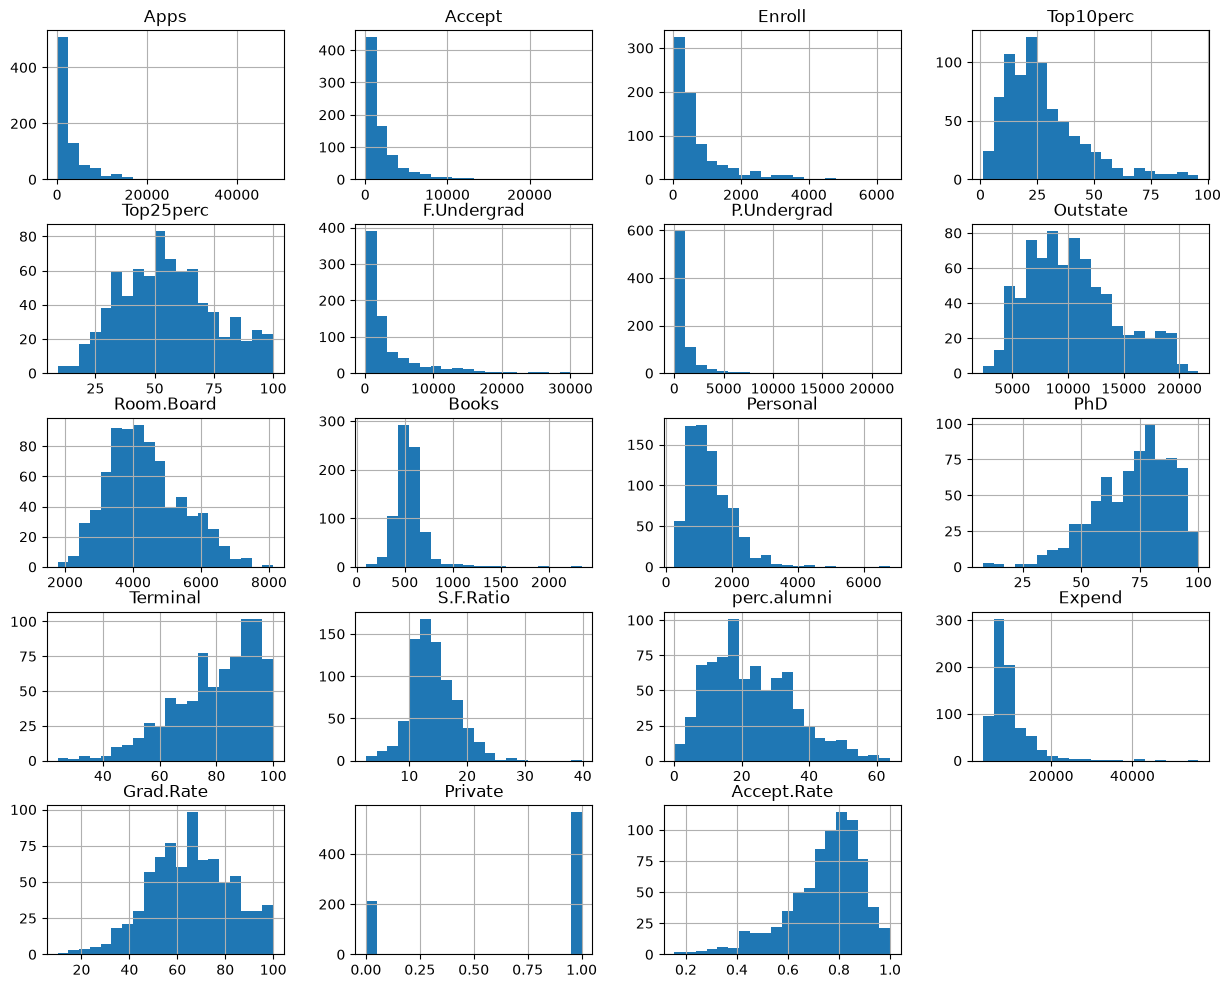

In [144]:
college_df[numerical_cols].hist(figsize=(15, 12), bins=20)
plt.show()

# EDA: Plot a Heatmap of the Correlation Matrix
---

Heatmaps are an effective way to visually examine the correlational structure of your predictors. 

1. Plot a heatmap
2. What features are highly correlated with each other? (use >=0.8 threshold value)
3. Any features leading to future/target-related leakage ?
4. Make a list of other features you recommend to drop based on the correlation value.

**NOTE**: Don't drop any column now, just make a list of features you plan not to use.

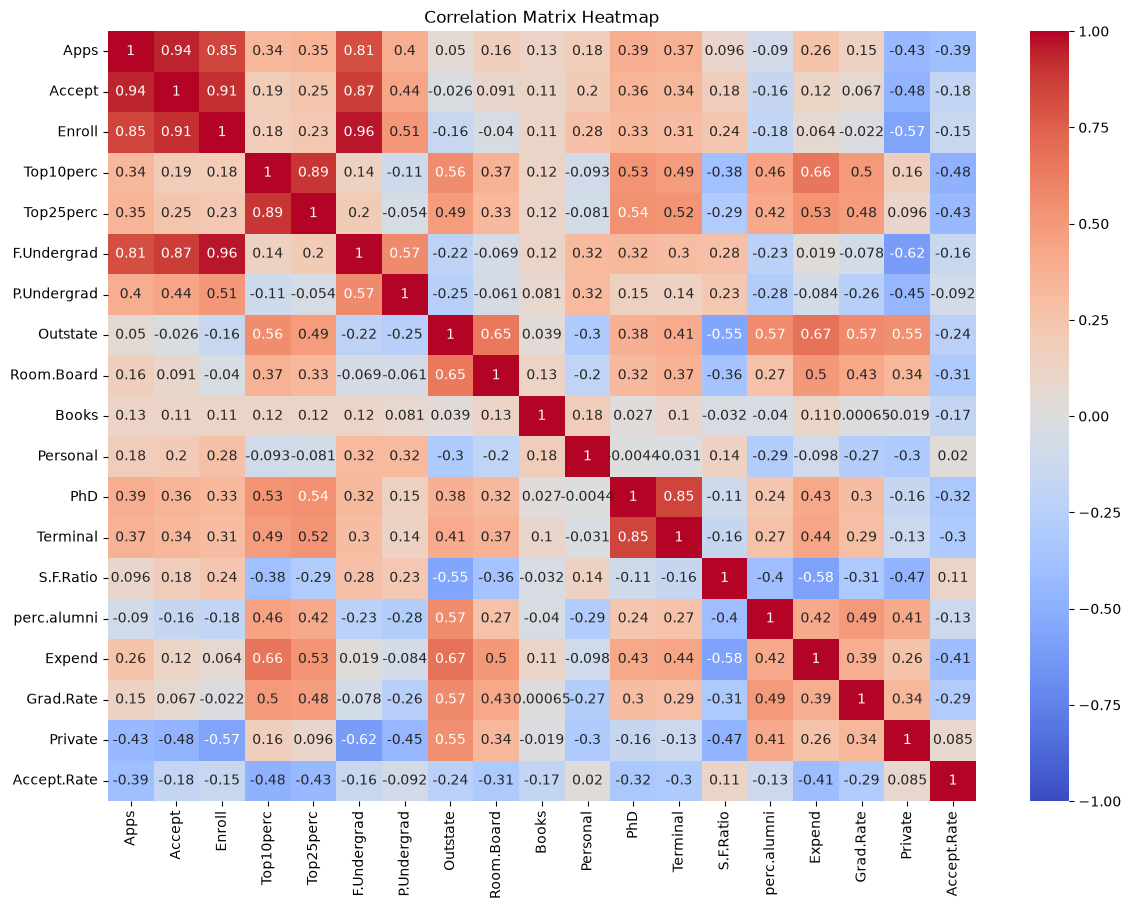

In [145]:
# 1.
college_corr = college_df[numerical_cols].corr()

plt.figure(figsize=(14, 10))

sns.heatmap(
    college_corr,
    annot=True,
    cmap='coolwarm',
    vmax=1,
    vmin=-1
)

plt.title('Correlation Matrix Heatmap')
plt.show()

In [146]:
# 2. 
# Identify multicollinearity (correlation >= 0.8 between features)

# Convert the correlation matrix into a DataFrame
corr_df = college_corr.stack().reset_index()

# Rename the columns
corr_df.columns = ['feature_1', 'feature_2', 'correlation']

# Remove self correlations
corr_df = corr_df[corr_df['feature_1'] != corr_df['feature_2']]

# Remove duplicate pairs: A-B vs B-A
corr_df = corr_df[corr_df['feature_1'] < corr_df['feature_2']]

# Remove target
corr_df = corr_df[
    (corr_df['feature_1'] != 'Apps') &
    (corr_df['feature_2'] != 'Apps')
]

# Compute absolute correlation
corr_df['absolute_correlation'] = np.abs(corr_df['correlation'])

# Sort from highest to lowest
corr_df = corr_df.sort_values(
    by='absolute_correlation',
    ascending=False
)

# Display correlations >= 0.8
threshold = 0.8
above_threshold = corr_df['absolute_correlation'] >= threshold

corr_df = corr_df[above_threshold]

# Final result
corr_df

,feature_1,feature_2,correlation,absolute_correlation
43,Enroll,F.Undergrad,0.964640,0.964640
21,Accept,Enroll,0.911637,0.911637
61,Top10perc,Top25perc,0.891995,0.891995
24,Accept,F.Undergrad,0.874223,0.874223
221,PhD,Terminal,0.848205,0.848205


In [147]:
# 3. 
college_df["Accept.Rate"] = college_df["Accept"] / college_df["Apps"]
leakage_features = ['Accept.Rate']


In [148]:
# 4.
features_to_drop = [
    'Accept.Rate'
]

In [149]:
#features_to_drop = [
#    'Accept.Rate',   # target leakage
#    'Enroll',        # highly correlated with Accept and F.Undergrad
#    'F.Undergrad',   # highly correlated with Enroll and Accept
#    'Top25perc',     # highly correlated with Top10perc
#    'Terminal'       # highly correlated with PhD
#]

##### What if I just wanted to look at the correlation to `apps`?

In [150]:
college_corr['Apps'].sort_values(ascending=False)

Apps           1.000000
Accept         0.943451
Enroll         0.846822
F.Undergrad    0.814491
P.Undergrad    0.398264
PhD            0.391922
Terminal       0.369491
Top25perc      0.351640
Top10perc      0.338834
Expend         0.259592
Personal       0.178731
Room.Board     0.164939
Grad.Rate      0.146964
Books          0.132559
S.F.Ratio      0.095633
Outstate       0.050159
perc.alumni   -0.090226
Accept.Rate   -0.392555
Private       -0.432095
Name: Apps, dtype: float64

# EDA: Use seaborn's `.pairplot()` method to create scatterplots 
---

1. Let's create a pairplot to see how some of our stronger predictors correlate to our target (`apps`). 
**HINT**: Instead of creating a pairplot of the entire DataFrame, we can use the `y_vars` and `x_vars` params to get a smaller subset.

2. Do you seen any linear relation between features and target? What transformation you recomment here?

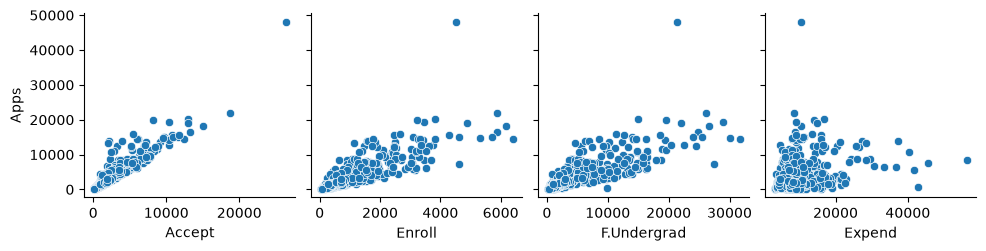

In [151]:
# 1.
sns.pairplot(
    data=college_df,
    y_vars=['Apps'],
    x_vars=['Accept', 'Enroll', 'F.Undergrad', 'Expend']
)

plt.show()


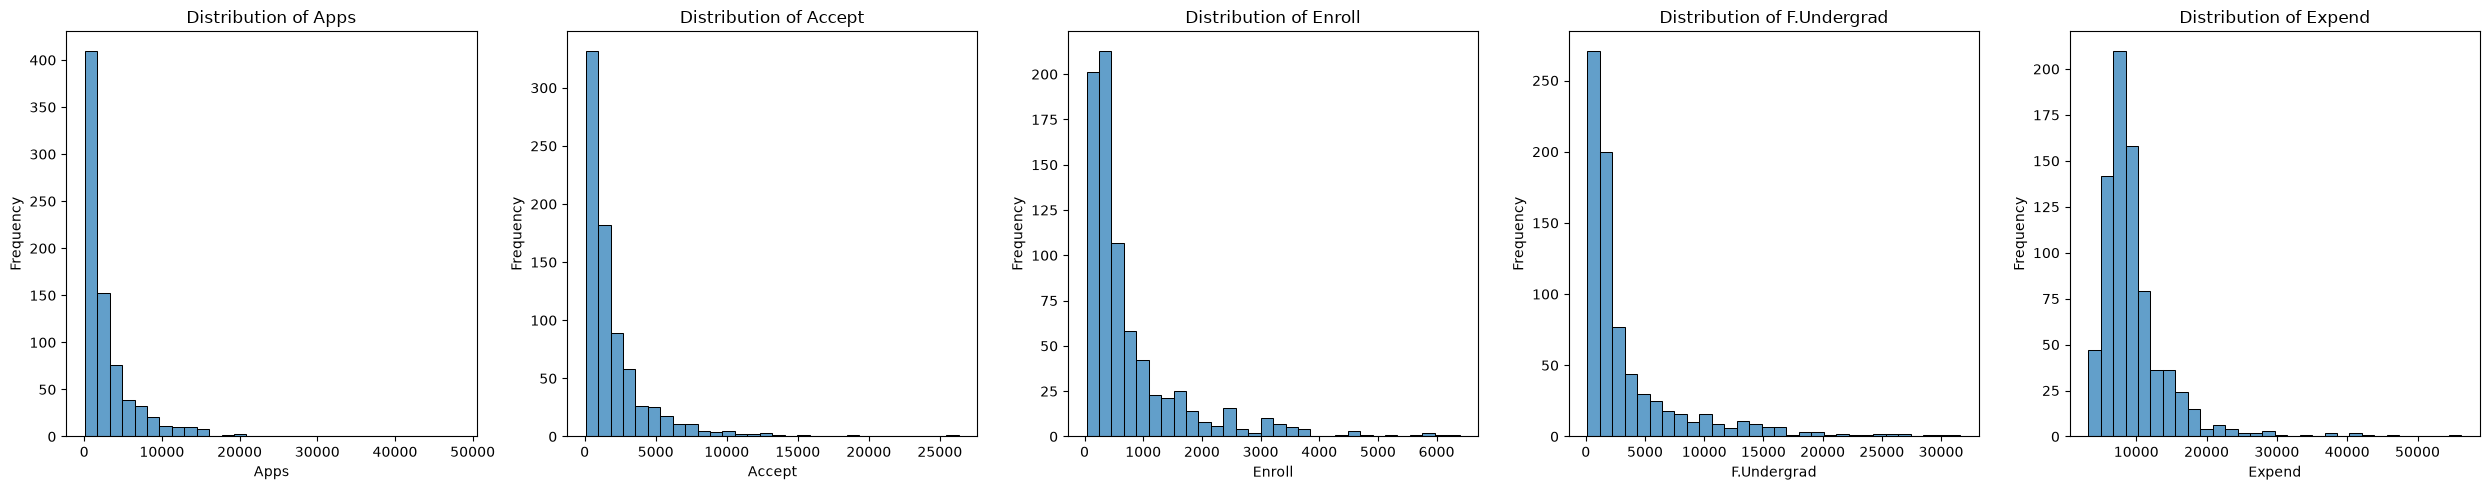

In [152]:
# Plot distributions of continuous variables
continuous_vars = ['Apps', 'Accept', 'Enroll', 'F.Undergrad', 'Expend']

fig, axes = plt.subplots(1, 5, figsize=(25, 5))

for i, var in enumerate(continuous_vars):
    sns.histplot(college_df[var], bins=30, alpha=0.7, ax=axes[i])
    axes[i].set_title(f'Distribution of {var}')
    axes[i].set_xlabel(var)
    axes[i].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

In [153]:
# 2. 
college_df['Apps_log'] = np.log1p(college_df['Apps'])
college_df['Accept_log'] = np.log1p(college_df['Accept'])
college_df['Enroll_log'] = np.log1p(college_df['Enroll'])
college_df['F.Undergrad_log'] = np.log1p(college_df['F.Undergrad'])
#I see a strong positive linear relationship between the first three features 
# (Accept, Enroll, and F.Undergrad) and the target (Apps). 
# Since these variables are right-skewed, 
# I recommend applying a log transformation to reduce the skewness and potentially 
# improve the linear relationship.


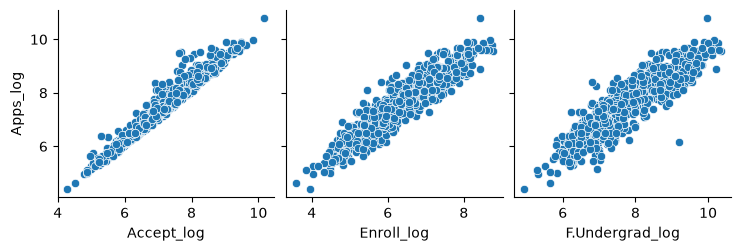

In [154]:
sns.pairplot(
    data=college_df,
    y_vars=['Apps_log'],
    x_vars=['Accept_log', 'Enroll_log', 'F.Undergrad_log']
)

plt.show()

# Model_1 Prep: Create our features matrix (`X`) and target vector (`y`)
---

What should our features be?

The `apps` column is our label: the number of applications received by that university.

In the cell below, create your `X` and `y` variables.

In [155]:
features_to_drop = [
    'University',       # High-cardinality identifier
    'Apps',             # Target variable
    'Apps_log',         # Target leakage: created directly from Apps
    'Accept.Rate',      # Target leakage: calculated using Apps
    'Accept_log',       # Excluded to avoid using both original and transformed version
    'Enroll_log',       # Excluded to avoid using both original and transformed version
    'F.Undergrad_log',  # Excluded to avoid using both original and transformed version
    'Enroll',           # Multicollinearity
    'F.Undergrad',      # Multicollinearity
    'Top25perc',        # Multicollinearity with Top10perc
    'Terminal'          # Multicollinearity with PhD
]

X = college_df.drop(columns=features_to_drop)
y = college_df['Apps']

In [156]:
X.head()

,Accept,Top10perc,P.Undergrad,Outstate,Room.Board,Books,Personal,PhD,S.F.Ratio,perc.alumni,Expend,Grad.Rate,Private,Outstate.Tier
0,1232,23,537,7440,3300,450,2200,70.0,18.1,12,7041,60,1,Low
1,1924,16,1227,12280,6450,750,1500,29.0,12.2,16,10527,56,1,High
2,1097,22,99,11250,3750,400,1165,53.0,12.9,30,8735,54,1,Medium
3,349,60,63,12960,5450,450,875,92.0,7.7,37,19016,59,1,High
4,146,16,869,7560,4120,800,1500,76.0,11.9,2,10922,15,1,Low


# Model_1 Prep: Train/test split
---

We always want to have a holdout set to test our model. Use the `train_test_split` function to split our `X` and `y` variables into a training set and a holdout set.

**HINT**: We have less than 1000 samples. Think of a suitable test size

In [157]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [158]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (621, 14)
X_test: (156, 14)
y_train: (621,)
y_test: (156,)


# Model_1 Prep: Imputing Missing Values
---

Some machine learning models cannot work with missing values (`NaN`), so we need to replace them before training.

An **imputer** fills missing values using a value learned from the data. For numerical features, a common approach is to replace missing values with the **mean** or **median**.

⚠️ **Why do we impute after the train/test split?**

The median/mean is calculated from the data. If we calculate it using the full dataset, information from the test set would leak into the training process.

Therefore:

- Fit the imputer using **`X_train` only**
- Use that same imputer to transform both **`X_train` and `X_test`**

Check this [doc](https://scikit-learn.org/stable/modules/generated/sklearn.impute.SimpleImputer.html) for more details

In the cell below:

1. Identify the numerical features containing missing values. Save them in a list
2. Instantiate a `SimpleImputer` using `strategy="median"`.
3. Fit the imputer on the training features containing missing values.
4. Transform both the training and test data ( Save the results back to **`X_train` and `X_test`**)

In [159]:
# 1. 
cols_impute = ['PhD']

In [160]:
# 2.
imputer = SimpleImputer(strategy='median')

In [161]:
# 3.
imputer.fit(X_train[cols_impute])

,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto account for missingness despite imputation. If a feature has nomissing values at fit/train time, the feature won't appear onthe missing indicator even if there are missing values attransform/test time.",False
,"keep_empty_features keep_empty_features: bool, default=FalseIf True, features that consist exclusively of missing values when`fit` is called are returned in results when `transform` is called.The imputed value is always `0` except when `strategy=""constant""`in which case `fill_value` will be used instead... versionadded:: 1.2",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['PhD']
indicator_ indicator_: :class:`~sklearn.impute.MissingIndicator`Indicator used to add binary indicators for missing values.`None` if `add_indicator=False`.,NoneType,None
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
"statistics_ statistics_: array of shape (n_features,)The imputation fill value for each feature.Computing statistics can result in `np.nan` values.During :meth:`transform`, features corresponding to `np.nan`statistics will be discarded.","ndarray[float64](1,)",[75.]


In [162]:
# 4.
X_train[cols_impute] = imputer.transform(X_train[cols_impute])
X_test[cols_impute] = imputer.transform(X_test[cols_impute])

In [163]:
X_train[cols_impute].isnull().sum()

PhD    0
dtype: int64

In [164]:
X_test[cols_impute].isnull().sum()

PhD    0
dtype: int64

# Model_1 Prep: Ordinal Encoding
---

In the cell below:

1. Identify the ordinal categorical features. Save them in a list
2. Instantiate the appropriate transformer
3. Fit the transformer on the training features containing missing values.
4. Transform both the training and test data ( Save the results back to **`X_train` and `X_test`**)|

In [165]:
# 1.
cols_ordinal = ['Outstate.Tier']

In [166]:
# 2.
tier_label = ['Low', 'Medium', 'High', 'Very High']

o_enc = OrdinalEncoder(
    categories=[tier_label]
).set_output(transform="pandas")

In [167]:
# 3.
o_enc.fit(X_train[cols_ordinal])

,"categories categories: 'auto' or a list of array-like, default='auto'Categories (unique values) per feature:- 'auto' : Determine categories automatically from the training data.- list : ``categories[i]`` holds the categories expected in the ith column. The passed categories should not mix strings and numeric values, and should be sorted in case of numeric values.The used categories can be found in the ``categories_`` attribute.","[['Low', 'Medium', ...]]"
,"dtype dtype: number type, default=np.float64Desired dtype of output.",<class 'numpy.float64'>
,"handle_unknown handle_unknown: {'error', 'use_encoded_value'}, default='error'When set to 'error' an error will be raised in case an unknowncategorical feature is present during transform. When set to'use_encoded_value', the encoded value of unknown categories will beset to the value given for the parameter `unknown_value`. In:meth:`inverse_transform`, an unknown category will be denoted as None... versionadded:: 0.24",'error'
,"unknown_value unknown_value: int or np.nan, default=NoneWhen the parameter handle_unknown is set to 'use_encoded_value', thisparameter is required and will set the encoded value of unknowncategories. It has to be distinct from the values used to encode any ofthe categories in `fit`. If set to np.nan, the `dtype` parameter mustbe a float dtype... versionadded:: 0.24",None
,"encoded_missing_value encoded_missing_value: int or np.nan, default=np.nanEncoded value of missing categories. If set to `np.nan`, then the `dtype`parameter must be a float dtype... versionadded:: 1.1",nan
,"min_frequency min_frequency: int or float, default=NoneSpecifies the minimum frequency below which a category will beconsidered infrequent.- If `int`, categories with a smaller cardinality will be considered infrequent.- If `float`, categories with a smaller cardinality than `min_frequency * n_samples` will be considered infrequent... versionadded:: 1.3 Read more in the :ref:`User Guide <encoder_infrequent_categories>`.",None
,"max_categories max_categories: int, default=NoneSpecifies an upper limit to the number of output categories for each inputfeature when considering infrequent categories. If there are infrequentcategories, `max_categories` includes the category representing theinfrequent categories along with the frequent categories. If `None`,there is no limit to the number of output features.`max_categories` do **not** take into account missing or unknowncategories. Setting `unknown_value` or `encoded_missing_value` to aninteger will increase the number of unique integer codes by one each.This can result in up to `max_categories + 2` integer codes... versionadded:: 1.3 Read more in the :ref:`User Guide <encoder_infrequent_categories>`.",None
Name,Type,Value
categories_ categories_: list of arraysThe categories of each feature determined during ``fit`` (in order ofthe features in X and corresponding with the output of ``transform``).This does not include categories that weren't seen during ``fit``.,list,"[array(['Low',... dtype=object)]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['Outstate.Tier']
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 1.0,int,1


In [168]:
# 4.
X_train[cols_ordinal] = o_enc.transform(X_train[cols_ordinal])
X_test[cols_ordinal] = o_enc.transform(X_test[cols_ordinal])

# Model_1 Prep: Robust Scaling
---

In the cell below:
1. Select the features to scale. Save them in a variable
2. Fit a `RobustScaler` to `X_train` and 
3. Use it to transform both `X_train` and `X_test`. 

**NOTE**: In real projects, we usually apply different scales based on the data distribution. For the sake of practice, we are just choosing one for all features

In [169]:
# 1.
cls_num = X_train.select_dtypes(include='number').columns

In [170]:
# 2. 
r_scaler = RobustScaler().set_output(transform='pandas')
r_scaler.fit(X_train[cls_num])


RobustScaler()

In [171]:
# 3.
X_train[cls_num] = r_scaler.transform(X_train[cls_num])
X_test[cls_num] = r_scaler.transform(X_test[cls_num])

# Model_1 Prep: Instantiate and train our model
---


In [172]:
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](14,)","[2422.29, 674.8 , -53.72,..., 219.81,-448.59,-612.71]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](14,)","['Accept','Top10perc','P.Undergrad',...,'Grad.Rate','Private', 'Outstate.Tier']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,1334
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,14
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(14)


# Model_1 Evaluation
---

Use `MAE` to evaluate the model.

1. Calculate the training MAE
2. Calculate the testing MAE
3. Do you think we are overfitting, underfitting?

In [173]:
# 1. 
y_train_pred = lr_model.predict(X_train)
y_train_mae = mean_absolute_error(y_train, y_train_pred)
print("Training MAE:", y_train_mae)
 

Training MAE: 587.6932892349201


In [174]:
# 2.
y_test_pred = lr_model.predict(X_test)
y_test_mae = mean_absolute_error(y_test, y_test_pred)
print("Testing MAE:", y_test_mae)


Testing MAE: 748.9997410807333


In [175]:
# 3.  
#The model shows some overfitting because the training MAE (587.69) is lower than the testing MAE (749.00). 
#This indicates that the model performs better on the training data than on unseen test data.


# Model_1 LINE Assumptions
---

1. Check the distribution of your errors
2. Check the equality of variace for your error

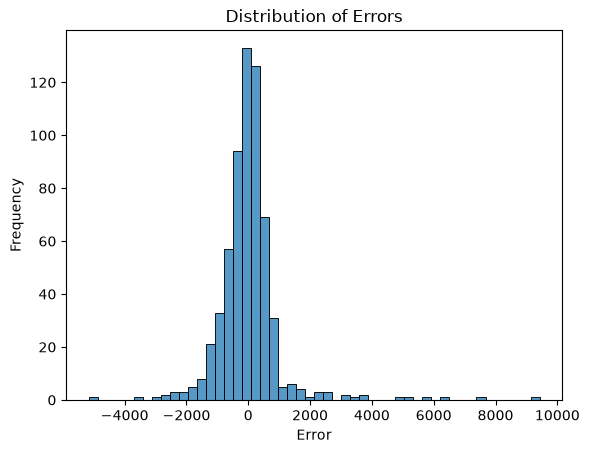

In [176]:
# N - Normality of errors
error = y_train - y_train_pred
sns.histplot(error)
plt.title('Distribution of Errors')
plt.xlabel('Error')
plt.ylabel('Frequency')
plt.show()

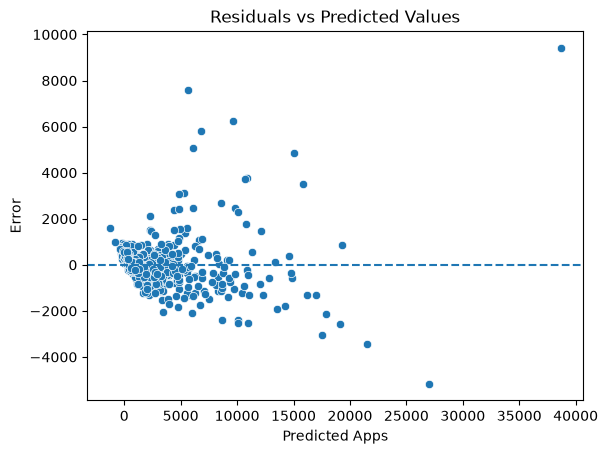

In [177]:
# E - Equal variance of errors
sns.scatterplot(x=y_train_pred, y=error)

plt.axhline(y=0, linestyle='--')
plt.title('Residuals vs Predicted Values')
plt.xlabel('Predicted Apps')
plt.ylabel('Error')
plt.show()

> Variance of the dependent variable varies and is not constant across the entire dataset.

# Model_2 Recommendations
---

We could now apply power transformations for the extremely skewed features/target and test if we get better results.

We will come back to this notebook after we introduce pipelines